# Demo 1 — probe retrieval (NFP) on a synthetic Siemens star

Near-field ptychography: one object, one distance, many sub-pixel scan
positions. From the intensities alone `RecNFP` recovers the **probe**, the
**projection** and the **positions**.

This is step 0 of the pipeline — the probe it produces is what step 6 would
be given as `prb_file`. One GPU, about 30 s at n = 512. The same run on
several GPUs: `./run_mpi.sh 4 01_nfp_probe.py`.

Everything is written out here; the notebook imports nothing but the package
itself.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..') + '/src')
from types import SimpleNamespace
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift
from mpi4py import MPI
from holotomocupy.logger_config import set_log_level

set_log_level('INFO')
comm = MPI.COMM_WORLD        # one rank here; the .py next door runs the same on N
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

GPU: Quadro RTX 8000


## The sample

A Siemens star: every spoke width appears at some radius, so one object probes every spatial frequency.

In [2]:
def siemens_star(nobj, step_deg=15):
    """(nobj, nobj) float32 Siemens-star mask, spokes every step_deg."""
    def rotate(pts, ang, c):
        s, co = np.sin(ang), np.cos(ang)
        return (pts - c) @ np.array([[co, -s], [s, co]], 'float32').T + c

    def tri(X, Y, t):
        (x1, y1), (x2, y2), (x3, y3) = t
        d = (y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3)
        if d == 0:
            return np.zeros_like(X, dtype=bool)
        a = ((y2 - y3) * (X - x3) + (x3 - x2) * (Y - y3)) / d
        b = ((y3 - y1) * (X - x3) + (x1 - x3) * (Y - y3)) / d
        return (a >= 0) & (b >= 0) & (1 - a - b >= 0)

    t0 = np.array([(1.5 * nobj // 16, nobj // 2 - nobj // 32),
                   (1.5 * nobj // 16, nobj // 2 + nobj // 32),
                   (nobj // 2 - nobj // 128, nobj // 2)], dtype='float32')
    yy, xx = np.mgrid[0:nobj, 0:nobj]
    c = np.array([nobj / 2, nobj / 2], dtype='float32')
    star = np.zeros((nobj, nobj), dtype='float32')
    for deg in range(0, 360, step_deg):
        star += tri(xx, yy, rotate(t0, np.deg2rad(deg), c)).astype('float32')
    return star / (star.max() or 1.0)


def star_projection(nobj, delta_beta=29.0, smooth=8.0):
    """complex64 transmission, -delta + i*beta, phase range [0, pi/8]."""
    star = siemens_star(nobj)
    v = np.arange(-nobj // 2, nobj // 2, dtype='float32') / nobj
    vx, vy = np.meshgrid(v, v, indexing='ij')
    g = fftshift(np.exp(-smooth * (vx**2 + vy**2)).astype('float32'))
    star = ifft2(fft2(star) * g).real
    star = star / star.max() * (np.pi / 8)
    return (-star + 1j * star / delta_beta).astype('complex64')

In [3]:
# The measured ID16A probe, cropped to the detector and smoothed.
def id16a_probe(n, ndist=1, smooth=4.0):
    from holotomocupy.utils import read_tiff
    a = read_tiff('data/prb_id16a/prb_abs_2048.tiff')[:ndist]
    p = read_tiff('data/prb_id16a/prb_phase_2048.tiff')[:ndist]
    prb = (a * np.exp(1j * p)).astype('complex64')
    c0, c1 = prb.shape[1] // 2, prb.shape[2] // 2
    prb = prb[:, c0 - n // 2:c0 + n // 2, c1 - n // 2:c1 + n // 2]
    v = np.arange(-n // 2, n // 2, dtype='float32') / n
    vx, vy = np.meshgrid(v, v, indexing='ij')
    filt = fftshift(np.exp(-smooth * (vx**2 + vy**2)).astype('float32'))
    prb = ifft2(fft2(prb) * filt).astype('complex64')
    return prb / np.mean(np.abs(prb), axis=(1, 2))[:, None, None]

In [4]:
def zoom(a, f=6):
    """The central 1/f of a 2-D array: the texture, not the support ring."""
    h, w = a.shape
    dh, dw = h // (2 * f), w // (2 * f)
    return a[h // 2 - dh:h // 2 + dh, w // 2 - dw:w // 2 + dw]


def panels(items, zoom_factor=6, cmap='gray', vref=None):
    """Each item as (full frame, {f}x zoom), on one grey scale."""
    ref = vref if vref is not None else items[-1][1]
    vmin, vmax = np.percentile(ref, [0.5, 99.5])
    fig, ax = plt.subplots(2, len(items), figsize=(4.2 * len(items), 8.4),
                           squeeze=False)
    for k, (lab, img) in enumerate(items):
        ax[0][k].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax[0][k].set_title(lab)
        ax[1][k].imshow(zoom(img, zoom_factor), cmap=cmap, vmin=vmin, vmax=vmax)
        ax[1][k].set_title(f'{lab} — {zoom_factor}x centre')
        for r in (0, 1):
            ax[r][k].axis('off')
    fig.tight_layout()

## Geometry, truth, and the object grid

object 576^2, detector 512^2, 16 positions within +-24 px


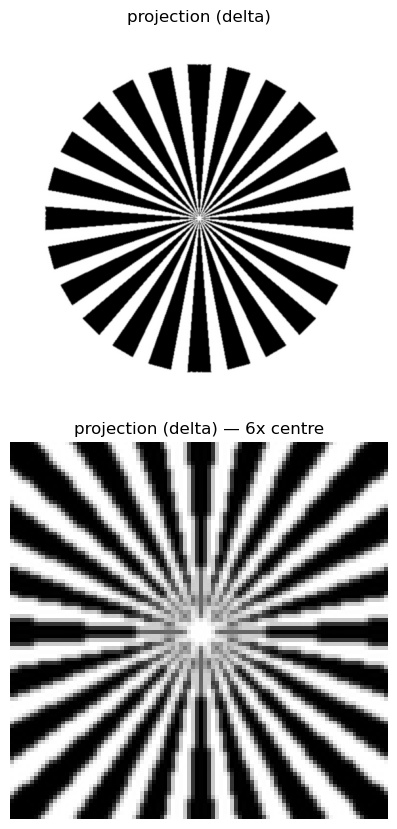

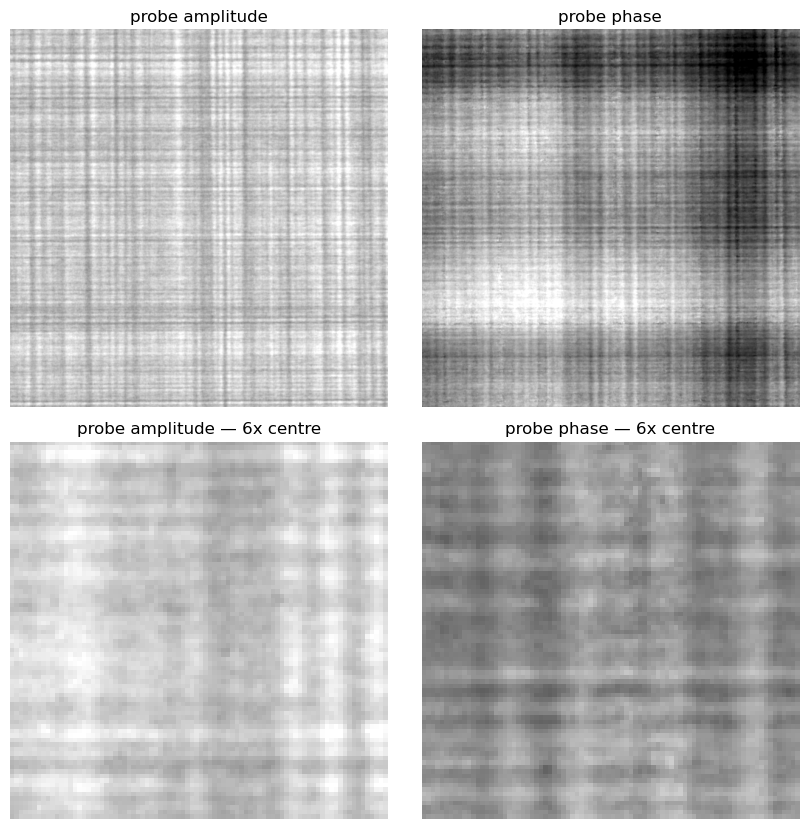

In [5]:
n, npos, niter = 512, 16, 257     # RecNFP calls the scan axis ntheta

rng     = np.random.default_rng(10)
pos_gt  = (30 / 512 * n * (rng.random((npos, 2)) - 0.5)).astype('float32')
pos_err = 4 * (rng.random((npos, 2)) - 0.5).astype('float32')
reach   = int(np.ceil(np.abs(pos_gt + pos_err).max())) + 8
nobj    = int(np.ceil((n + 2 * reach) / 32)) * 32   # must contain every shift

proj_gt = star_projection(nobj)
prb_gt  = id16a_probe(n)[0]
print(f'object {nobj}^2, detector {n}^2, {npos} positions within +-{reach} px')

panels([('projection (delta)', proj_gt.real)])
panels([('probe amplitude', np.abs(prb_gt)), ('probe phase', np.angle(prb_gt))])

## Forward: simulate the measured intensities

/home/beams2/VNIKITIN/holotomocupy_gpu_reduced/src/holotomocupy/propagation.py:44: UserWarning: mathDX not found at /local/vnikitin/nvidia-mathdx-25.12.1-cuda13/nvidia/mathdx/25.12 (include/ or example/cufftdx/ missing). Set MATHDX_ROOT to your mathDX installation. Falling back to cuPy FFT.
  self._use_cufftdx = cufftdx_available()


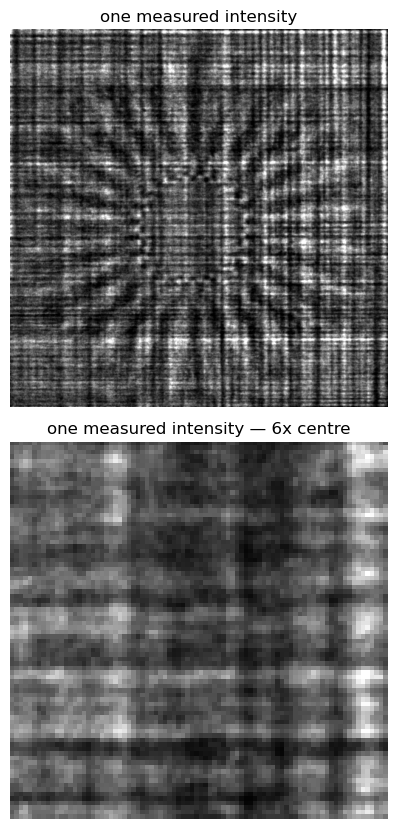

In [6]:
from holotomocupy.rec_nfp_mpi import RecNFP

args = SimpleNamespace(
    energy=17.1, detector_pixelsize=1.4760147601476e-6 * 4,
    focustodetectordistance=1.217, z1=5.110e-3,
    ntheta=npos, nz=n, n=n, nzobj=nobj, nobj=nobj,
    rho=[1, 2, 0.1], niter=niter, nchunk=8,
    checkpoint_step=niter // 4, error_step=niter // 8, start_iter=0,
    psf_sigma=0.0, shift_type='fft', path_out='./demo_out/nfp', comm=comm)
cl = RecNFP(args)

cl.vars['proj'][:] = cp.asarray(proj_gt)
cl.vars['prb'][:]  = cp.asarray(prb_gt)
cl.vars['pos'][:]  = cp.asarray(pos_gt)
cl.gen_data(cl.vars, cl.data)

panels([('one measured intensity', cp.asnumpy(cl.data[0]))])

## Step 5's trick in 2-D: a Paganin start

A real NFP scan measures a flat field — the probe with no sample — so the
same recipe step 5 uses applies here: normalise by the flat, stitch the
overlapping positions onto the object grid, invert once.

Two details decide whether it is any use at all:

* **where no frame reached, the transmission is 1** (no sample). Dividing by
  a near-zero weight instead leaves a garbage rim, and the Fourier filter
  spreads that rim over the whole frame — correlation with the truth 0.43
  instead of 0.81.
* the phase comes out with the sign the object has, so it goes in as `+ph`.

Measured below: it takes the final projection from 0.83 to **0.96**.

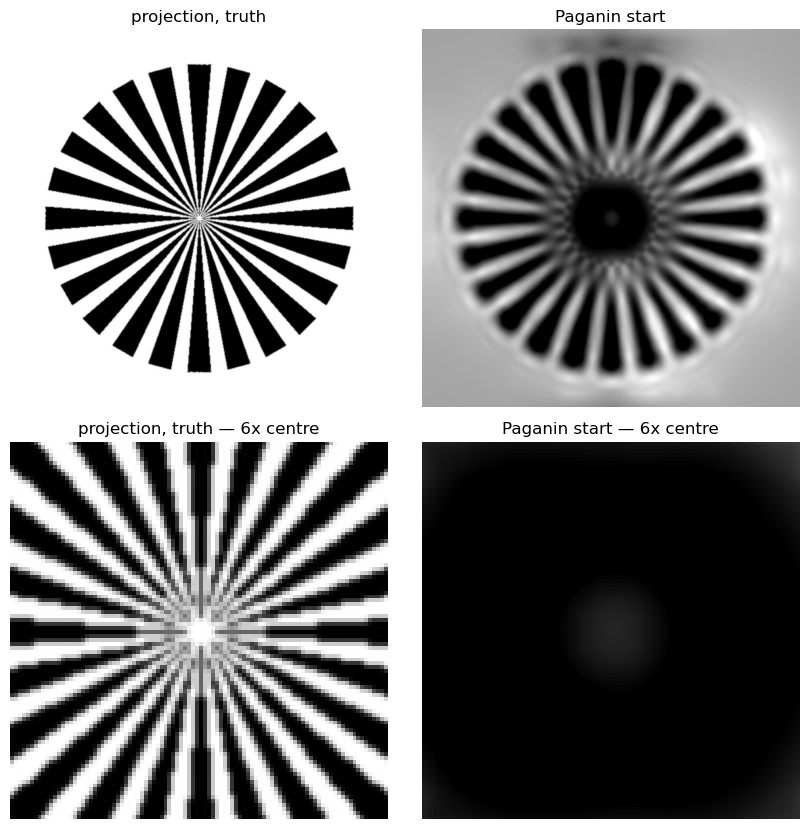

In [7]:
def multi_paganin(data, distances, wavelength, voxelsize, delta_beta, alpha=1e-2):
    """Phase from [ndist, ny, nx] flat-field-normalised intensities.

    One distance here, which is the classic single-distance Paganin filter.
    """
    fx = cp.fft.fftfreq(data.shape[-1], d=voxelsize).astype('float32')
    fy = cp.fft.fftfreq(data.shape[-2], d=voxelsize).astype('float32')
    fx, fy = cp.meshgrid(fx, fy)
    num = den = 0
    for j in range(data.shape[0]):
        taylor = 1 + wavelength * distances[j] * cp.pi * delta_beta * (fx**2 + fy**2)
        num += taylor * cp.fft.fft2(data[j].astype('complex64'))
        den += taylor**2
    num /= len(distances)
    den = den / len(distances) + alpha
    return cp.log(cp.real(cp.fft.ifft2(num / den))) * delta_beta * 0.5


# the measured flat field: the probe, no sample
u = cl.cl_prop.D(cp.asarray(prb_gt)[None], 0)
ref = (cp.abs(u) ** 2)[0]

pos0 = pos_gt + pos_err
ones = cp.ones((1, n, n), dtype='complex64')
mm = cp.ones((1, 2), dtype='float32')
acc = cp.zeros((nobj, nobj), dtype='complex64')
wt = cp.zeros((nobj, nobj), dtype='float32')
for i in range(npos):
    r = cp.asarray(pos0[i:i + 1])
    rd = cp.asarray(cl.data[i:i + 1]) / (ref + 1e-5)
    big = cl.cl_shift.curlySback(cp.log(rd.astype('complex64')), r, mm)[0]
    one = cl.cl_shift.curlySback(ones, r, mm)[0].real
    acc += cp.exp(big) * one
    wt += one
# .real, not .astype: acc is complex and astype would drop the
# imaginary part silently (ComplexWarning)
rdata = cp.where(wt > 0.05, acc / cp.maximum(wt, 1e-3), 1.0).real

ph = multi_paganin(rdata[None], cl.cl_prop.distance,
                   cl.cl_prop.wavelength, cl.cl_prop.voxelsize, 29.0)
proj0 = cp.asnumpy((ph + 1j * ph / 29.0).astype('complex64'))

panels([('projection, truth', proj_gt.real),
        ('Paganin start', proj0.real)], vref=proj_gt.real)

## Inverse

That projection, a flat probe, and positions wrong by ~1 px.

In [8]:
cl.vars['proj'][:] = cp.asarray(proj0)   # was 0; --paganin 0 in the script
cl.vars['prb'][:]  = 1
cl.vars['pos'][:]  = cp.asarray(pos0)
cl.BH()

pos = cp.asnumpy(cl.vars['pos'])
print(f'position error {np.abs(pos - pos_gt).mean():.4f} px, '
      f'from {np.abs(pos_err).mean():.4f}')

2026-10-03 15:46:17 [rank=0] Initial err=2.26121e-01


2026-10-03 15:46:17 [rank=0]   pos err y: [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]


2026-10-03 15:46:17 [rank=0]   pos err x: [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]


2026-10-03 15:46:18 [rank=0] iter=0: 0.6930sec err=3.28387e-01


2026-10-03 15:46:18 [rank=0]   pos err y: [-0.0044,  0.005 ,  0.0043,  0.0009, -0.0076,  0.0038, -0.0008, -0.0011,
 -0.0038,  0.003 , -0.0102, -0.0081, -0.0005, -0.0038,  0.0009,  0.0052]


...

2026-10-03 15:48:53 [rank=0] iter=256: 20.1719sec err=1.78631e-05


2026-10-03 15:48:53 [rank=0]   pos err y: [-1.5252,  0.9112,  1.4239,  0.4354, -1.3732,  0.6024,  0.1434, -0.335 ,
 -0.5502,  1.0535, -1.9657, -1.3907,  0.1448, -0.3327,  0.8944,  1.7089]


2026-10-03 15:48:53 [rank=0]   pos err x: [-0.2103,  1.5939,  1.196 , -0.4228, -0.9357,  1.5931,  0.4228,  0.6764,
  1.7166, -0.8985, -1.0602, -1.0138, -0.7683,  0.3752, -1.2823, -1.0795]


2026-10-03 15:48:53 [rank=0] Saving iter 256: proj, prb to ./demo_out/nfp/checkpoints_tiff


position error 0.1028 px, from 0.9512


The 6x zoom is where the fine spokes are — the whole frame is dominated by the coarse ones and hides what was actually recovered.

projection correlation: start 0.8095  ->  recovered 0.9609


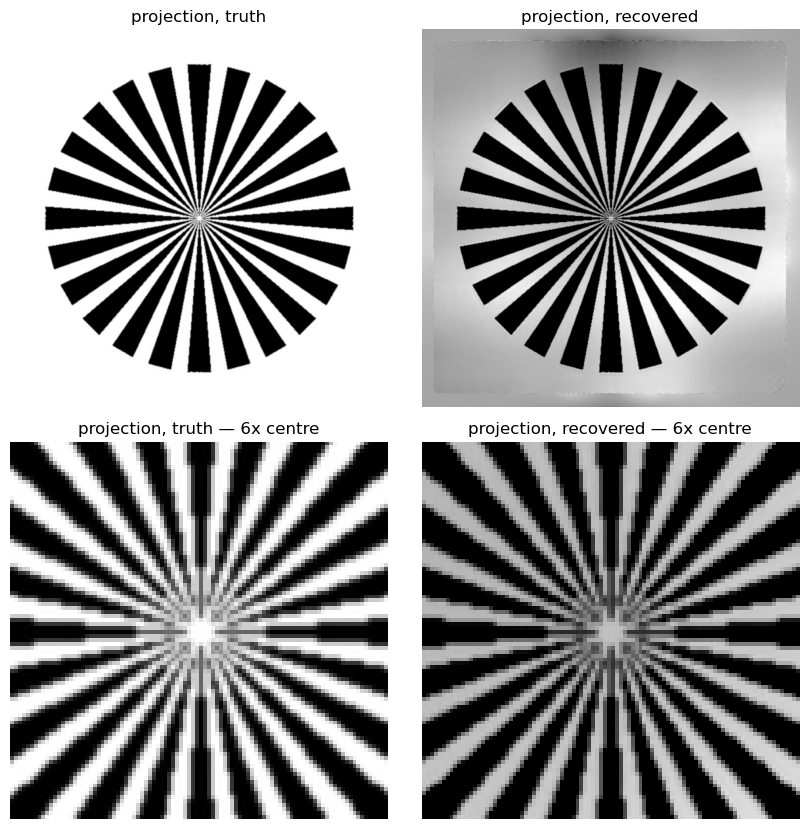

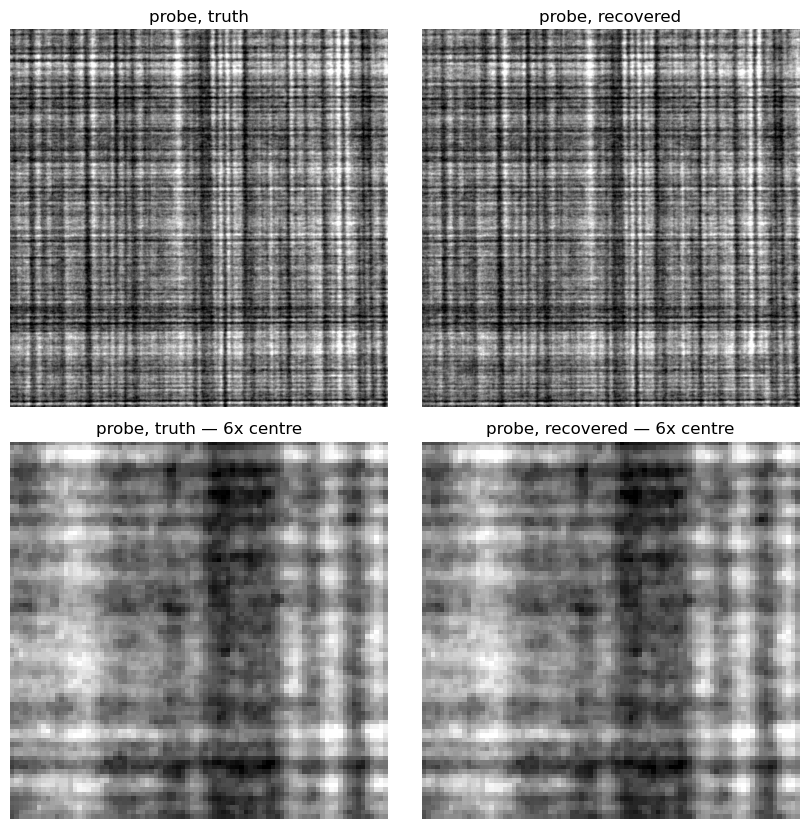

In [9]:
proj = cp.asnumpy(cl.vars['proj'])
prb  = cp.asnumpy(cl.vars['prb'])


def corr(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float((a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum()))


print(f'projection correlation: start {corr(proj0.real, proj_gt.real):.4f}'
      f'  ->  recovered {corr(proj.real, proj_gt.real):.4f}')
panels([('projection, truth', proj_gt.real),
        ('projection, recovered', proj.real)], vref=proj_gt.real)
panels([('probe, truth', np.abs(prb_gt)),
        ('probe, recovered', np.abs(prb))], vref=np.abs(prb_gt))